In [1]:
#import Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Tech Challenge 2 - WineQT/Input/WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
#Visão Geral do dataset
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores faltantes por coluna:")
print(df.isnull().sum())
print("\nEstatísticas gerais:")
df.describe()

Formato do dataset: (1143, 13)

Tipos de dados:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Valores faltantes por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Estatísticas gerais:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


RESULTADO: 1.143 Amostras, 0 valores faltantes, qualidade varia de 3 a 8 tendo uma média de ~5,6.

In [4]:
# Removendo a coluna Id
df = df.drop(columns=['Id'])

# Criando a variável alvo binária
# Alta Qualidade = 1 (nota >= 7)
# Baixa/Média Qualidade = 0 (nota < 7)
df['target'] = (df['quality'] >= 7).astype(int)

# Verificando o balanceamento das classes
print("Distribuição da variável alvo:")
print(df['target'].value_counts())
print("\nEm porcentagem:")
print(df['target'].value_counts(normalize=True).round(2) * 100)

Distribuição da variável alvo:
target
0    984
1    159
Name: count, dtype: int64

Em porcentagem:
target
0    86.0
1    14.0
Name: proportion, dtype: float64


Resultado: 86% baixa qualidade, 14% alta qualidade. O dataset é severamente desbalanceado.

/tmp/ipykernel_1277/770369873.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


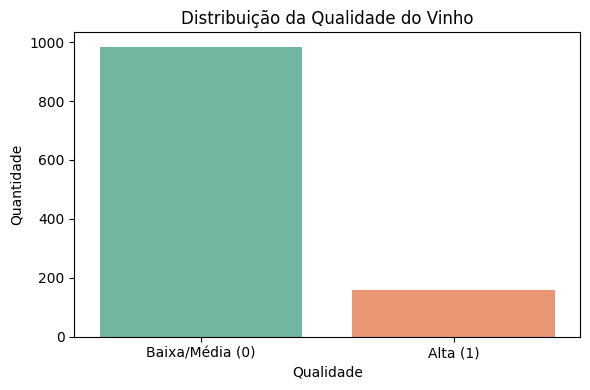

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribuição da variável alvo
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribuição da Qualidade do Vinho')
plt.xticks([0, 1], ['Baixa/Média (0)', 'Alta (1)'])
plt.xlabel('Qualidade')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=150)
plt.show()

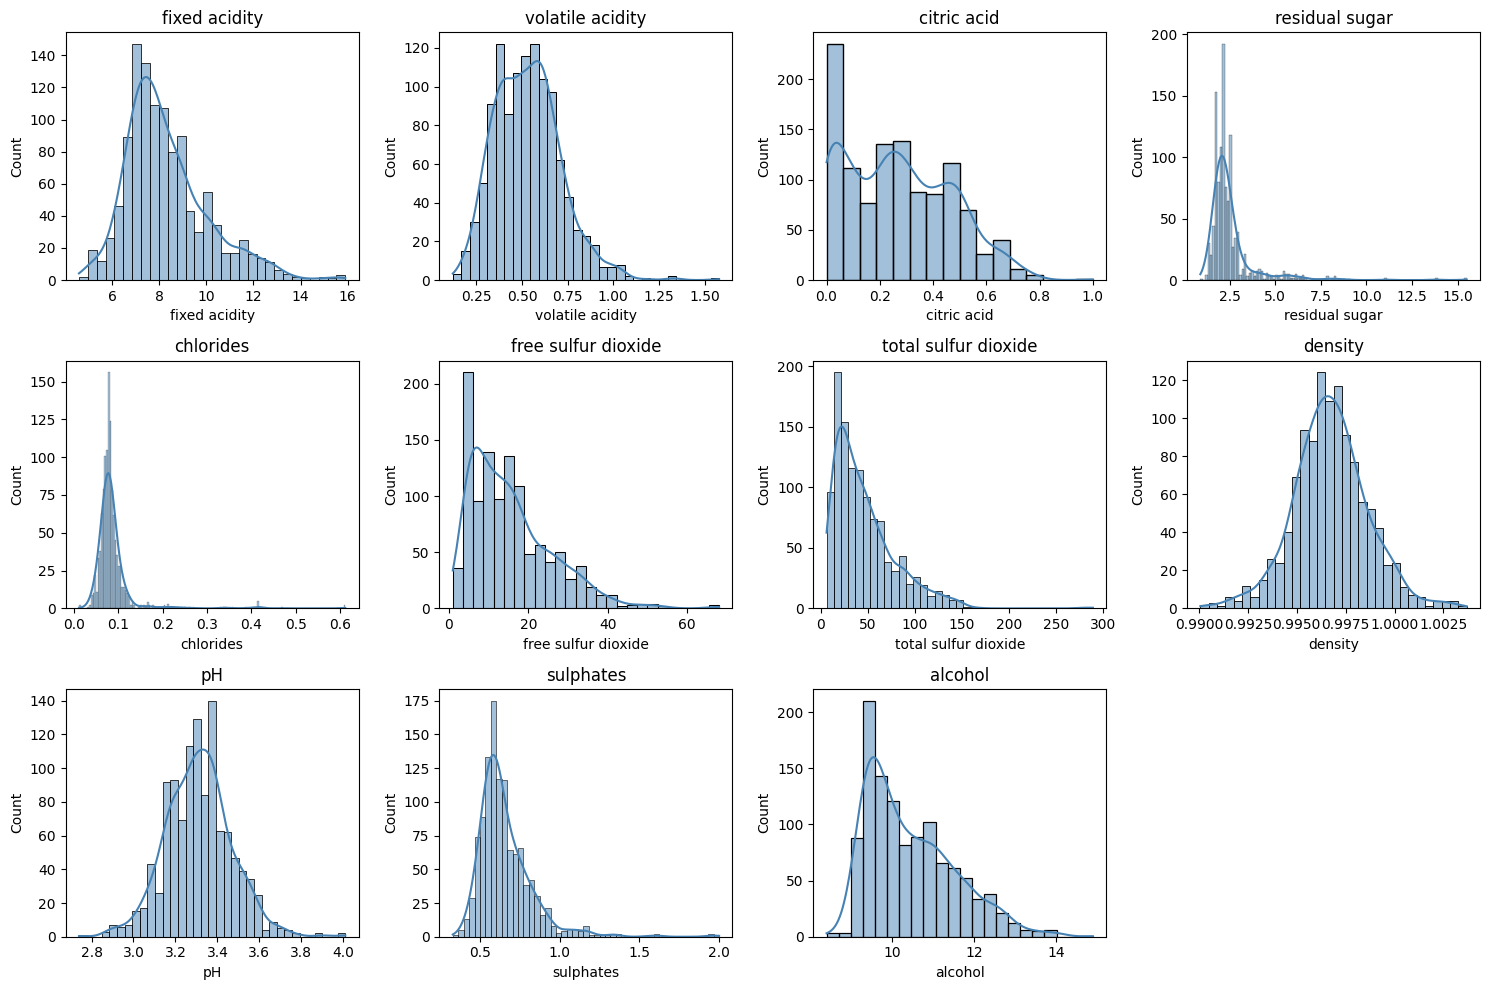

In [6]:
# Distribuição de todas as variáveis numéricas
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(col)
    plt.tight_layout()

plt.savefig('distribuicao_variaveis.png', dpi=150)
plt.show()

1. chlorides, residual sugar, sulphates — caudas longas à direita, indicam outliers (valores extremos)

2. density e pH — distribuição bem comportada, quase normal

3. alcohol - concentrado entre 9-11, com alguns vinhos bem mais alcoólicos

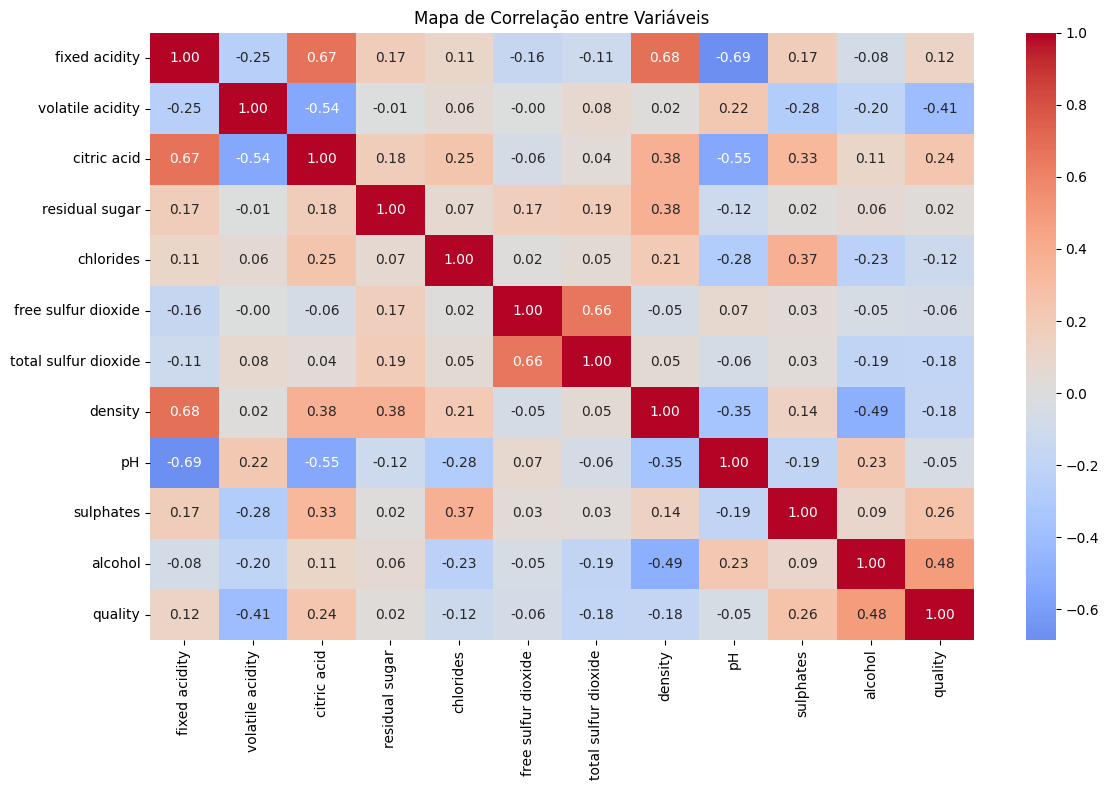

In [7]:
# Mapa de correlação
plt.figure(figsize=(12, 8))
corr = df.drop(columns=['target']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de Correlação entre Variáveis')
plt.tight_layout()
plt.savefig('correlacao.png', dpi=150)
plt.show()

Correlações com quality:

1. alcohol → +0.48 — maior correlação positiva. Vinhos mais alcoólicos tendem a ser melhores
2. volatile acidity → -0.41 — correlação negativa forte.
3. Muita acidez volátil prejudica a qualidade
4. sulphates → +0.26 — leve positivo
5. citric acid → +0.24 — leve positivo
6. density → -0.18 — leve negativo

/tmp/ipykernel_1277/1470235183.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, palette='Set2')
/tmp/ipykernel_1277/1470235183.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, palette='Set2')
/tmp/ipykernel_1277/1470235183.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, palette='Set2')
/tmp/ipykernel_1277/1470235183.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

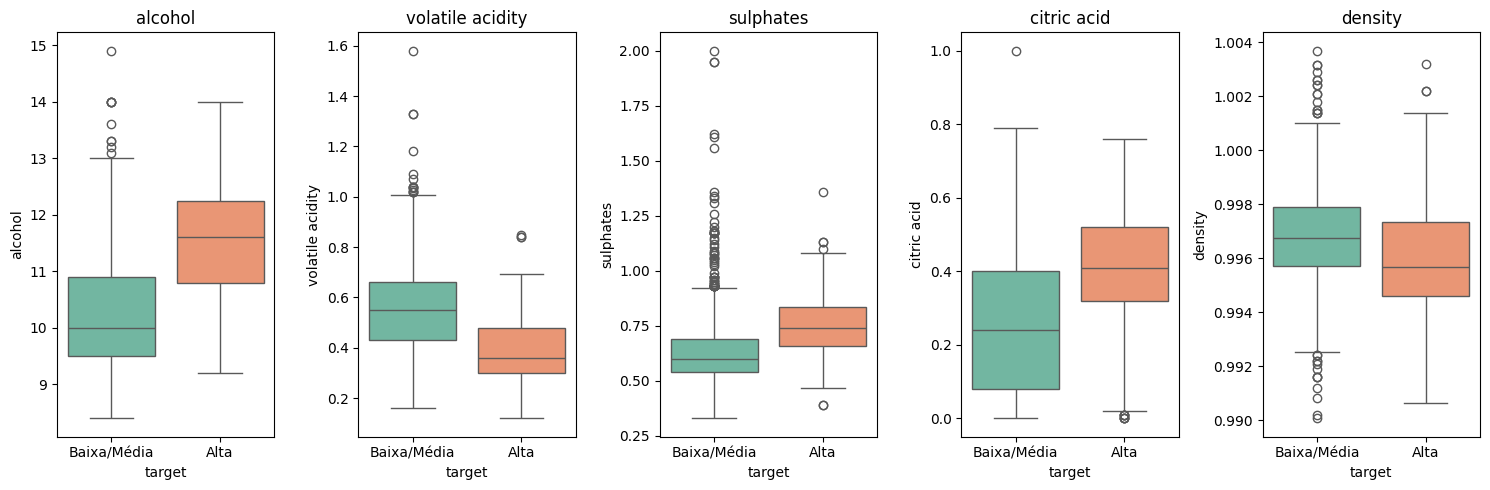

In [8]:
# Boxplots das variáveis mais relevantes por classe
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density']

plt.figure(figsize=(15, 5))
for i, col in enumerate(top_features):
    plt.subplot(1, 5, i+1)
    sns.boxplot(x='target', y=col, data=df, palette='Set2')
    plt.xticks([0, 1], ['Baixa/Média', 'Alta'])
    plt.title(col)
    plt.tight_layout()

plt.savefig('boxplots.png', dpi=150)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separando features e variável alvo
X = df.drop(columns=['quality', 'target'])
y = df['target']

# Dividindo em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizando as variáveis numéricas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

Tamanho do treino: (914, 11)
Tamanho do teste: (229, 11)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Modelo 1 - Regressão Logística
lr = LogisticRegression(random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Modelo 2 - Random Forest
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Regressão Logística ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]).round(3))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]).round(3))

=== Regressão Logística ===
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       197
           1       0.38      0.69      0.49        32

    accuracy                           0.80       229
   macro avg       0.66      0.75      0.68       229
weighted avg       0.86      0.80      0.82       229

ROC-AUC: 0.85

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       197
           1       0.83      0.47      0.60        32

    accuracy                           0.91       229
   macro avg       0.88      0.73      0.78       229
weighted avg       0.91      0.91      0.90       229

ROC-AUC: 0.901


Regressão Logística:

Recall de 0.69 na classe Alta Qualidade — encontrou 69% dos vinhos bons
Precision baixa (0.38) — gerou muitos falsos positivos
ROC-AUC de 0.85 — boa capacidade geral

Random Forest:

Precision alta (0.83) na classe Alta Qualidade — quando disse "bom", acertou 83% das vezes
Recall baixo (0.47) — perdeu mais da metade dos vinhos bons
ROC-AUC de 0.901 — melhor capacidade geral

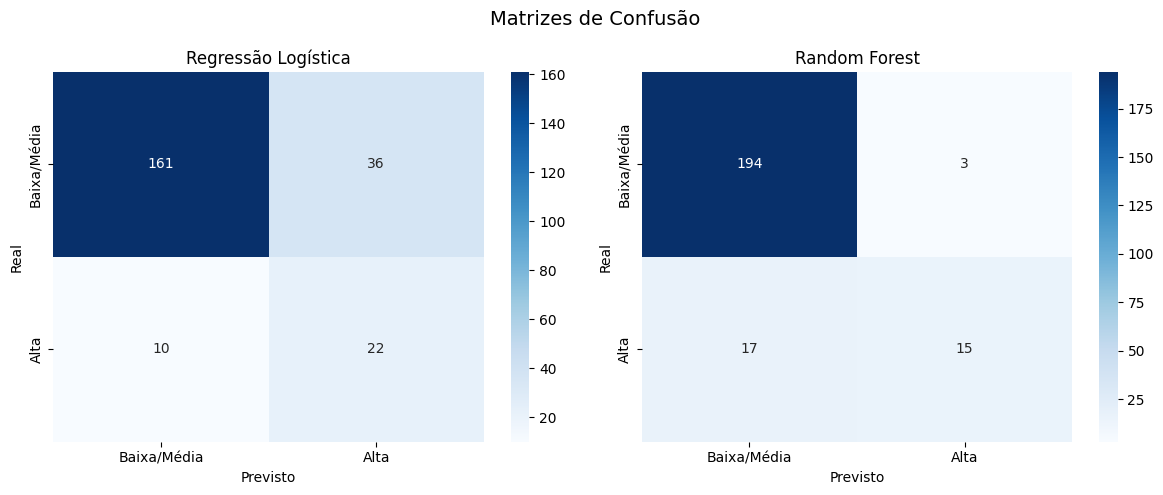

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusão - Regressão Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baixa/Média', 'Alta'],
            yticklabels=['Baixa/Média', 'Alta'])
axes[0].set_title('Regressão Logística')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# Matriz de confusão - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Baixa/Média', 'Alta'],
            yticklabels=['Baixa/Média', 'Alta'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.suptitle('Matrizes de Confusão', fontsize=14)
plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150)
plt.show()

Regressão Logística:

Acertou 161 vinhos Baixa/Média e 22 vinhos Alta;
Errou 36 dizendo Alta mas era Baixa/Média e 10 dizendo Baixa/Média mas era Alta

Random Forest:

Acertou 194 vinhos Baixa/Média e 15 vinhos Alta;
Errou apenas 3 dizendo Alta mas era Baixa/Média e 17 dizendo Baixa/Média mas era Alta


O Random Forest é muito mais preciso na classe majoritária, mas perde mais vinhos de alta qualidade. A Regressão Logística encontra mais vinhos bons, mas gera mais alarmes falsos.

/tmp/ipykernel_1277/3348371592.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


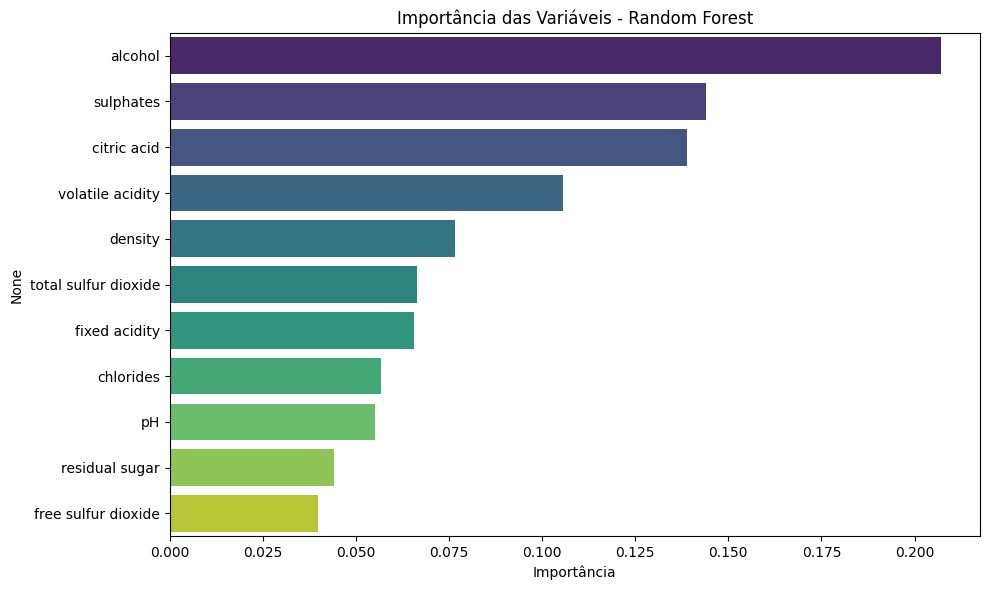

In [12]:
# Feature importance do Random Forest
importances = rf.feature_importances_
feature_names = df.drop(columns=['quality', 'target']).columns
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [14]:
# Tabela comparativa dos modelos
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 3),
        round(accuracy_score(y_test, y_pred_rf), 3)
    ],
    'Precision (Alta)': [
        round(precision_score(y_test, y_pred_lr), 3),
        round(precision_score(y_test, y_pred_rf), 3)
    ],
    'Recall (Alta)': [
        round(recall_score(y_test, y_pred_lr), 3),
        round(recall_score(y_test, y_pred_rf), 3)
    ],
    'F1-Score (Alta)': [
        round(f1_score(y_test, y_pred_lr), 3),
        round(f1_score(y_test, y_pred_rf), 3)
    ],
    'ROC-AUC': [0.850, 0.901]
})

print(resultados.to_string(index=False))

             Modelo  Accuracy  Precision (Alta)  Recall (Alta)  F1-Score (Alta)  ROC-AUC
Regressão Logística     0.799             0.379          0.688            0.489    0.850
      Random Forest     0.913             0.833          0.469            0.600    0.901
